# Introduction


This notebook is intended to clean and analyze datasets related to sociooeconomic factors and ACT performance in high schoolers during the year 2016.


We are trying to determine which, if any, socioeconomic factors might affect school performance, and we are using ACT/SAT scores as a proxy. I have added an additional variable to determine if offering athletic opportunities has any impact on academic performance.

Where is data from:

1. EdGap.org. This data set from 2016 includes information about average ACT or SAT scores for schools and several socioeconomic characteristics of the school district.
2. The secondary data set is basic information about each school from the National Center for Education Statistics.https://www.ncei.noaa.gov/cdo-web/search?datasetid=GHCND
3. The tertiary dataset contains information about student teacher ratio from nces.ed.gov/ccd/elsi/tableGenerator.aspx

This notebook will output a cleaned education dataset and generate several graphs as part of the data exploration and analysis.


# Load and explore the data

## Import libraries

In [1]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn is a data visualization library built on matplotlib
import seaborn as sns
import plotly.offline as po
import plotly.graph_objs as pg

# Machine learning
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler

# Modeling
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Model metrics and analysis
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.anova import anova_lm



# set the plotting style
sns.set_style("whitegrid")

## Load the data

##### Load the EdGap data set from Github repo/ data folder

In [2]:
edgap = pd.read_excel(
    
    'https://raw.githubusercontent.com/ayoung42/education/main/data/EdGap_data.xlsx',
    dtype={'NCESSCH School ID': object}
)

C:\Users\ahria\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning:

Unknown extension is not supported and will be removed



##### Download the school information data from Dropbox link

In [3]:
school_information= pd.read_csv("https://www.dropbox.com/s/lkl5nvcdmwyoban/ccd_sch_029_1617_w_1a_11212017.csv?dl=1", encoding='unicode_escape',low_memory= False)

##### Download offerings information from data folder

In [4]:
ratio_csv = '../data/ELSI_csv_export_6389666757884058993012.csv'
ratio= pd.read_csv(ratio_csv, skiprows=5)

## Explore the contents of the data sets

##### Start by looking at the head of each data frame.
This will let us see the names of the columns and a few example values for each column. We can also check whether the data is in tidy format.

In [5]:
pd.set_option('display.max_columns', None)
edgap.head()

,NCESSCH School ID,CT Unemployment Rate,CT Pct Adults with College Degree,CT Pct Childre In Married Couple Family,CT Median Household Income,School ACT average (or equivalent if SAT score),School Pct Free and Reduced Lunch
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641


##### School information data set

In [6]:
school_information.head()

,SCHOOL_YEAR,FIPST,STATENAME,ST,SCH_NAME,LEA_NAME,STATE_AGENCY_NO,UNION,ST_LEAID,LEAID,ST_SCHID,NCESSCH,SCHID,MSTREET1,MSTREET2,MSTREET3,MCITY,MSTATE,MZIP,MZIP4,LSTREET1,LSTREET2,LSTREET3,LCITY,LSTATE,LZIP,LZIP4,PHONE,WEBSITE,SY_STATUS,SY_STATUS_TEXT,UPDATED_STATUS,UPDATED_STATUS_TEXT,EFFECTIVE_DATE,SCH_TYPE_TEXT,SCH_TYPE,RECON_STATUS,OUT_OF_STATE_FLAG,CHARTER_TEXT,CHARTAUTH1,CHARTAUTHN1,CHARTAUTH2,CHARTAUTHN2,NOGRADES,G_PK_OFFERED,G_KG_OFFERED,G_1_OFFERED,G_2_OFFERED,G_3_OFFERED,G_4_OFFERED,G_5_OFFERED,G_6_OFFERED,G_7_OFFERED,G_8_OFFERED,G_9_OFFERED,G_10_OFFERED,G_11_OFFERED,G_12_OFFERED,G_13_OFFERED,G_UG_OFFERED,G_AE_OFFERED,GSLO,GSHI,LEVEL,IGOFFERED
0,2016-2017,1,ALABAMA,AL,Sequoyah Sch - Chalkville Campus,Alabama Youth Services,01,NaN,AL-210,0100002,AL-210-0020,1.000020e+10,100277.0,P O Box 9486,NaN,NaN,Birmingham,AL,35220,NaN,1000 Industrial School Road,NaN,NaN,Birmingham,AL,35220,NaN,(205)680-8574,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported
1,2016-2017,1,ALABAMA,AL,Camps,Alabama Youth Services,01,NaN,AL-210,0100002,AL-210-0050,1.000020e+10,101667.0,P O Box 66,NaN,NaN,Mt Meigs,AL,36057,NaN,1601 County Rd. 57,NaN,NaN,Prattville,AL,36067,NaN,(334)215-3850,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported
2,2016-2017,1,ALABAMA,AL,Det Ctr,Alabama Youth Services,01,NaN,AL-210,0100002,AL-210-0060,1.000020e+10,101670.0,P O Box 66,NaN,NaN,Mt Meigs,AL,36057,NaN,2109 Bashi Rd Bldg 509,NaN,NaN,Thomasville,AL,36784,NaN,(334)215-3850,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported
3,2016-2017,1,ALABAMA,AL,Wallace Sch - Mt Meigs Campus,Alabama Youth Services,01,NaN,AL-210,0100002,AL-210-0030,1.000020e+10,101705.0,P O Box 66,NaN,NaN,Mount Meigs,AL,36057,NaN,1000 Industrial School Road,NaN,NaN,Mount Meigs,AL,36057,NaN,(334)215-6039,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported
4,2016-2017,1,ALABAMA,AL,McNeel Sch - Vacca Campus,Alabama Youth Services,01,NaN,AL-210,0100002,AL-210-0040,1.000020e+10,101706.0,8950 Roebuck Blvd,NaN,NaN,Birmingham,AL,35206,NaN,8950 Roebuck Blvd,NaN,NaN,Birmingham,AL,35206,NaN,(205)838-4981,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported


##### Ratio dataset

In [7]:
ratio.head()

,School Name,State Name [Public School] Latest available year,State Name [Public School] 2016-17,School ID (12-digit) - NCES Assigned [Public School] Latest available year,Location City [Public School] 2016-17,Location State Abbr [Public School] 2016-17,Location ZIP [Public School] 2016-17,Grade 12 offered [Public School] 2016-17,Grade 11 offered [Public School] 2016-17,Pupil/Teacher Ratio [Public School] 2016-17
0,1 LT CHARLES W. WHITCOMB SCHOOL,Massachusetts,MASSACHUSETTS,2.507320e+11,Marlborough,MA,01752,2-No,2-No,11.22
1,100 ACADEMY OF ENGINEERING AND TECHNOLOGY ES,Nevada,NEVADA,3.200060e+11,North Las Vegas,NV,89032,2-No,2-No,21.28
2,100 ACADEMY OF ENGINEERING AND TECHNOLOGY MS,Nevada,NEVADA,3.200060e+11,North Las Vegas,NV,89032,2-No,2-No,39.33
3,10TH STREET SCHOOL,Washington,WASHINGTON,5.304860e+11,Marysville,WA,98271,2-No,2-No,24.79
4,112 ALC INDEPENDENT STUDY,Minnesota,MINNESOTA,2.708190e+11,CHASKA,MN,55317,1-Yes,1-Yes,†


##### Use the `info` method to check the data types, size of the data frame, and numbers of missing values.

In [8]:
edgap.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7986 entries, 0 to 7985
Data columns (total 7 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   NCESSCH School ID                                7986 non-null   object 
 1   CT Unemployment Rate                             7972 non-null   float64
 2   CT Pct Adults with College Degree                7973 non-null   float64
 3   CT Pct Childre In Married Couple Family          7961 non-null   float64
 4   CT Median Household Income                       7966 non-null   float64
 5   School ACT average (or equivalent if SAT score)  7986 non-null   float64
 6   School Pct Free and Reduced Lunch                7986 non-null   float64
dtypes: float64(6), object(1)
memory usage: 436.9+ KB


##### School information data set

In [9]:
school_information.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102183 entries, 0 to 102182
Data columns (total 65 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   SCHOOL_YEAR          102183 non-null  object 
 1   FIPST                102183 non-null  int64  
 2   STATENAME            102183 non-null  object 
 3   ST                   102183 non-null  object 
 4   SCH_NAME             102183 non-null  object 
 5   LEA_NAME             102183 non-null  object 
 6   STATE_AGENCY_NO      102183 non-null  object 
 7   UNION                2533 non-null    float64
 8   ST_LEAID             102183 non-null  object 
 9   LEAID                102183 non-null  object 
 10  ST_SCHID             102183 non-null  object 
 11  NCESSCH              102181 non-null  float64
 12  SCHID                102181 non-null  float64
 13  MSTREET1             102181 non-null  object 
 14  MSTREET2             1825 non-null    object 
 15  MSTREET3         

In [10]:
ratio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99857 entries, 0 to 99856
Data columns (total 10 columns):
 #   Column                                                                      Non-Null Count  Dtype  
---  ------                                                                      --------------  -----  
 0   School Name                                                                 99857 non-null  object 
 1   State Name [Public School] Latest available year                            99853 non-null  object 
 2   State Name [Public School] 2016-17                                          99853 non-null  object 
 3   School ID (12-digit) - NCES Assigned [Public School] Latest available year  99853 non-null  float64
 4   Location City [Public School] 2016-17                                       99853 non-null  object 
 5   Location State Abbr [Public School] 2016-17                                 99853 non-null  object 
 6   Location ZIP [Public School] 2016-17          

## Summary

1.  The school information and ratio data sets are much larger than the EdGap data set. Clearly the EdGap data set does not include all schools.

2.  There are missing values in each data set.

3.  Each data set is in a tidy, or long format.

4.  The data types for the variables of interest look correct, but the school identifier is an `object` in the `EdGap` and `ratio` data set and a `float64` in the school information data set.

# Are the data suitable for answering the question?

We want to perform quick exploratory data analysis to determine whether the data are sufficient to answer our question. If the data are not sufficient, we do not want to waste time doing anything that will not be productive.


Make a pair plot to explore relationships between the variables.

##### Add regression lines and format the pair plot

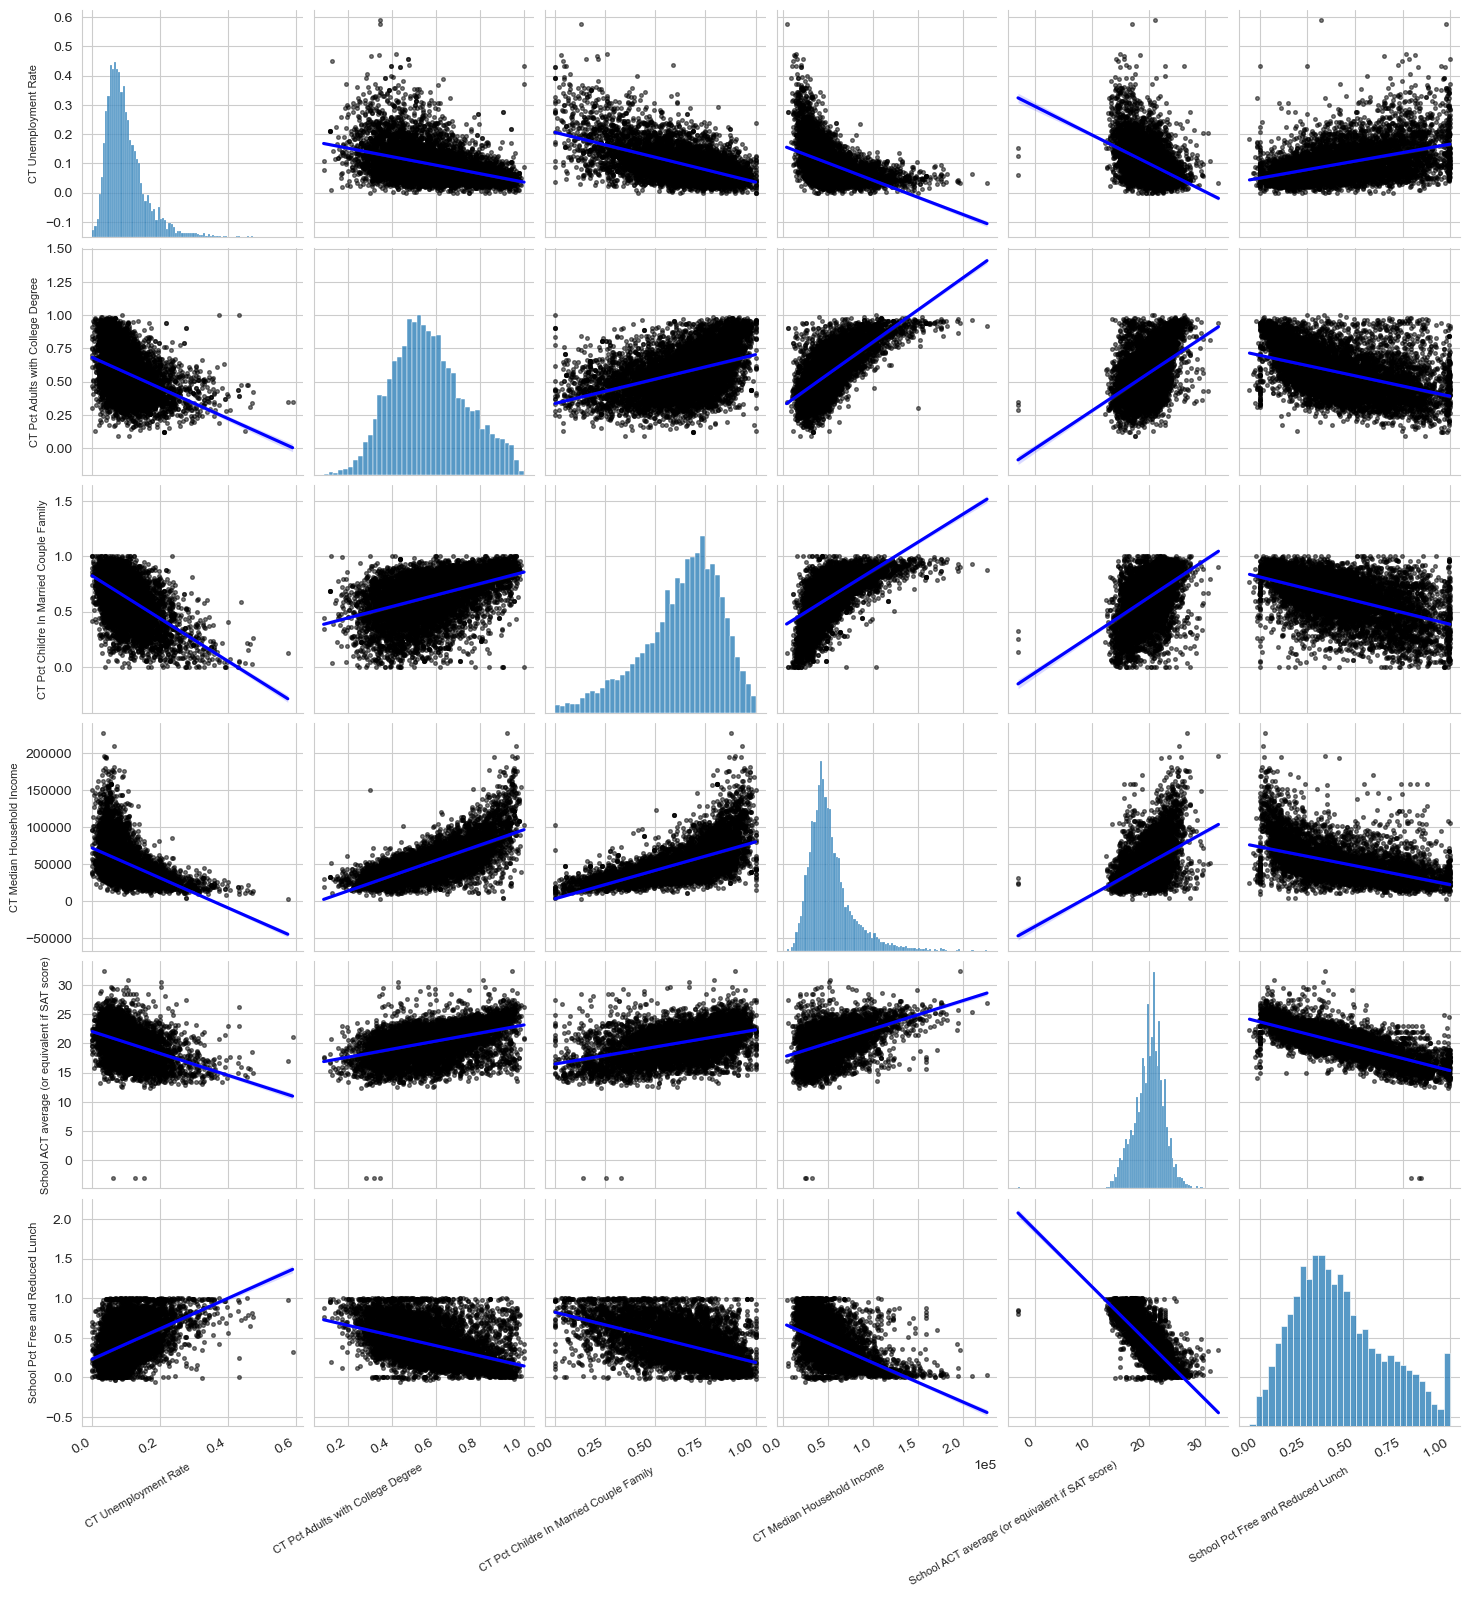

In [11]:
fig = sns.pairplot(
    edgap.drop(columns="NCESSCH School ID"),
    kind="reg",
    plot_kws={
        "line_kws": {"color": "blue"},
        "scatter_kws": {"alpha": 0.5, "color": "k", "s": 7},
    },
)

for ax in fig.axes.flat:
    if ax.get_xlabel() == 'CT Median Household Income':
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))  # Apply scientific notation
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right')  # X-axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8)  # Y-axis label size

    # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')


plt.show()

##### Plot a single row. We will select the ACT Average row so we can focus on the relationship between socioeconomic factors and ACT scores.

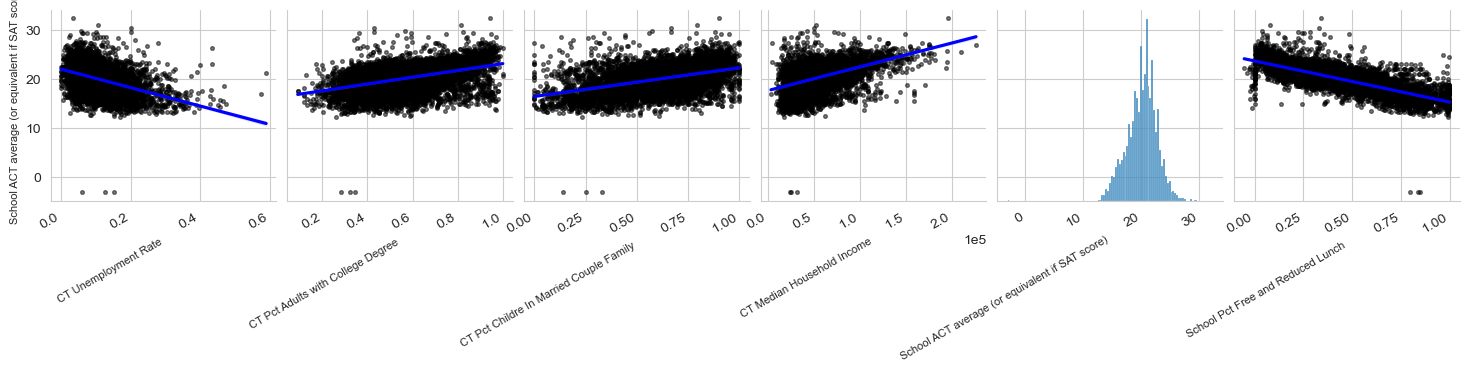

In [12]:
fig = sns.pairplot(
    edgap.drop(columns="NCESSCH School ID"),
    y_vars=['School ACT average (or equivalent if SAT score)'],
    kind="reg",
    plot_kws={
        "line_kws": {"color": "blue"},
        "scatter_kws": {"alpha": 0.5, "color": "k", "s": 7},
    },
)

for ax in fig.axes.flat:
    if ax.get_xlabel() == 'CT Median Household Income':
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))  # Apply scientific notation
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right')  # X-axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8)  # Y-axis label size

    # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.show()

## Summary

1. There appears to be a relationship between the socioeconomic variables and the ACT score. Unemployment rate and school lunch is negatively correlated. Adult with degree, married couple, and median household income are postively correlated.

2.  There are some out-of-range ACT and percent lunch values that will need to be dealt with.

3.  We should have confidence that it is worthwhile to spend time preparing the data for analysis.

# Data Preparation

## Select relevant subsets of the data

The school information data set contains many columns. We only need the year, school identity, location, and school type information.

Keep the columns `SCHOOL_YEAR`, `NCESSCH`, `LSTATE`, `LZIP`, `SCH_TYPE_TEXT`, `LEVEL`, `CHARTER_TEXT`

In [13]:
school_information = school_information[
    ['SCHOOL_YEAR', 'NCESSCH', 'LSTATE', 'LZIP', 'SCH_TYPE_TEXT', 'LEVEL', 'CHARTER_TEXT']
]

In [14]:
school_information.head()

,SCHOOL_YEAR,NCESSCH,LSTATE,LZIP,SCH_TYPE_TEXT,LEVEL,CHARTER_TEXT
0,2016-2017,1.000020e+10,AL,35220,Alternative School,High,No
1,2016-2017,1.000020e+10,AL,36067,Alternative School,High,No
2,2016-2017,1.000020e+10,AL,36784,Alternative School,High,No
3,2016-2017,1.000020e+10,AL,36057,Alternative School,High,No
4,2016-2017,1.000020e+10,AL,35206,Alternative School,High,No


## Rename columns

We will rename the columns to follow best practices of style and being informative. We can do this before or after joining the data sets.

In [15]:
edgap = edgap.rename(
    columns={
        "NCESSCH School ID": "id",
        "CT Pct Adults with College Degree": "percent_college",
        "CT Unemployment Rate": "rate_unemployment",
        "CT Pct Childre In Married Couple Family": "percent_married",
        "CT Median Household Income": "median_income",
        "School ACT average (or equivalent if SAT score)": "average_act",
        "School Pct Free and Reduced Lunch": "percent_lunch",
    }
)

##### Rename the columns `SCHOOL_YEAR`, `NCESSCH`, `LSTATE`, `LZIP`, `SCH_TYPE_TEXT`, `LEVEL`, `CHARTER_TEXT` to `year`, `id`, `state`, `zip_code`, `school_type`, `school_level`, `charter`

In [16]:
school_information = school_information.rename(
    columns={
        "SCHOOL_YEAR": "year",
        "NCESSCH": "id",
        "LSTATE": "state",
        "LZIP": "zip_code",
        "SCH_TYPE_TEXT": "school_type",
        "LEVEL": "school_level",
        "CHARTER_TEXT": "charter"
    }
)

In [17]:
school_information.head()

,year,id,state,zip_code,school_type,school_level,charter
0,2016-2017,1.000020e+10,AL,35220,Alternative School,High,No
1,2016-2017,1.000020e+10,AL,36067,Alternative School,High,No
2,2016-2017,1.000020e+10,AL,36784,Alternative School,High,No
3,2016-2017,1.000020e+10,AL,36057,Alternative School,High,No
4,2016-2017,1.000020e+10,AL,35206,Alternative School,High,No


In [18]:
ratio = ratio.rename(
    columns= {
        'School ID (12-digit) - NCES Assigned [Public School] Latest available year': 'id',
        'School Name': 'school',
        'Location ZIP [Public School] 2016-17': 'zip_code',
        'Location State Abbr [Public School] 2016-17': 'state',
        'Grade 12 offered [Public School] 2016-17': 'school_level',
        'Pupil/Teacher Ratio [Public School] 2016-17': 'st_ratio'   
    }
)

In [19]:
ratio = ratio[
    ['id', 'school', 'st_ratio']
]

## Summary

1. We selected a subset of columns of the school information data set.

2.  We renamed the columns for clarity and to follow formatting guidelines.

3.  We are ready to join the data frames.

# Join data frames

We want to join the DataFrames using the identity of the school as the key. The identity is given by the NCESSCH school identity. The value is an `object` in the ratio and EdGap data set but a `float64` in the school information data set.

We will cast the `id` column in the `school_information` DataFrame as an `object`.

In [20]:
school_information['id'] = school_information['id'].astype('object')

#### First merge ratio and school information datasets

In [21]:
merged_df_1_2 = pd.merge(ratio, school_information, on='id', how='inner')

In [22]:
merged_df_1_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99173 entries, 0 to 99172
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            99165 non-null  object
 1   school        99173 non-null  object
 2   st_ratio      99165 non-null  object
 3   year          99173 non-null  object
 4   state         99173 non-null  object
 5   zip_code      99173 non-null  object
 6   school_type   99171 non-null  object
 7   school_level  99163 non-null  object
 8   charter       99163 non-null  object
dtypes: object(9)
memory usage: 6.8+ MB


#### Join the data frames and call the result `df`.

In [23]:
df = edgap.merge(
    merged_df_1_2,
    how='left',
    on='id'
)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7986 entries, 0 to 7985
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 7986 non-null   object 
 1   rate_unemployment  7972 non-null   float64
 2   percent_college    7973 non-null   float64
 3   percent_married    7961 non-null   float64
 4   median_income      7966 non-null   float64
 5   average_act        7986 non-null   float64
 6   percent_lunch      7986 non-null   float64
 7   school             7865 non-null   object 
 8   st_ratio           7865 non-null   object 
 9   year               7865 non-null   object 
 10  state              7865 non-null   object 
 11  zip_code           7865 non-null   object 
 12  school_type        7865 non-null   object 
 13  school_level       7865 non-null   object 
 14  charter            7865 non-null   object 
dtypes: float64(6), object(9)
memory usage: 936.0+ KB


## Summary

1. We joined the data sets using the school `id` as the key.

2. We first cast the `id` as an object to have the same data type for the key in each data set.

3. We used a left join to keep all EdGap data.

# Quality Control

##### There are natural bounds for the numerical variables in the data set. Check the minimum and maximum values in each column.

In [25]:
df['st_ratio'] = pd.to_numeric(df['st_ratio'], errors='coerce')

In [26]:
df.select_dtypes(include=['number']).agg(['min', 'max', 'mean']).round(2)

,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,st_ratio
min,0.00,0.09,0.00,3589.00,-3.07,-0.05,3.86
max,0.59,1.00,1.00,226181.00,32.36,1.00,6592.00
mean,0.10,0.57,0.63,52026.91,20.18,0.42,17.11


##### Set out-of-range values to `NaN` using `np.nan`.

In [27]:
df.loc[df['st_ratio'] > 80, 'st_ratio'] = np.nan

In [28]:
df.loc[df['percent_lunch'] < 0, 'percent_lunch'] = np.nan

In [29]:
df.loc[df['average_act'] < 1, 'average_act'] = np.nan

##### Check the types, levels, and charter status of schools

In [30]:
df['school_type'].value_counts()

school_type
Regular School                 7852
Alternative School               10
Special Education School          2
Career and Technical School       1
Name: count, dtype: int64

In [31]:
df['school_level'].value_counts()

school_level
High            7230
Other            631
Elementary         2
Not reported       2
Name: count, dtype: int64

In [32]:
df['charter'].value_counts()

charter
No                7300
Yes                349
Not applicable     216
Name: count, dtype: int64

##### Keep only the high schools.

In [33]:
df = df.loc[df['school_level'] == 'High']

##### Check for any duplicated rows

In [34]:
df.duplicated().sum()

np.int64(0)

## Identify missing values

#### How many values of each variable are missing?

In [35]:
df.isna().sum().to_frame(name='Number of Missing Values')

,Number of Missing Values
id,0
rate_unemployment,12
percent_college,11
percent_married,20
median_income,16
average_act,3
percent_lunch,20
school,0
st_ratio,19
year,0


#### What percentage of values of each variable are missing?

In [36]:
percent_missing = df.isna().mean().round(4) * 100

percent_missing.to_frame(name='Percent Missing Values')

,Percent Missing Values
id,0.00
rate_unemployment,0.17
percent_college,0.15
percent_married,0.28
median_income,0.22
average_act,0.04
percent_lunch,0.28
school,0.00
st_ratio,0.26
year,0.00


##### What states do we have data from?

In [37]:
df['state'].value_counts()

state
TX    913
OH    654
IL    564
PA    543
MI    498
NC    407
FL    404
GA    367
WI    351
NJ    341
MO    337
IN    321
NY    295
TN    265
WA    263
MA    253
KY    198
LA    194
WY     38
DE     24
Name: count, dtype: int64

In [38]:
df['state'].nunique()

20

#### Plot the results on a map

In [39]:
layout = dict(
    geo={"scope": "usa"}, coloraxis_colorbar=dict(title="Number of Schools")
)

data = dict(
    type="choropleth",
    locations=df["state"].value_counts().index,
    locationmode="USA-states",
    z=df["state"].value_counts().values,
    coloraxis="coloraxis",
)

x = pg.Figure(data=[data], layout=layout)

po.iplot(x)

##### We are missing a large amount of USA data due to omission. This is not evident by examining `NaN` values in the data set.



##### Drop the rows where the average ACT score is missing


In [40]:
df = df.dropna(subset=['average_act'])

In [41]:
df.isna().sum().to_frame(name='Number of Missing Values')

,Number of Missing Values
id,0
rate_unemployment,12
percent_college,11
percent_married,20
median_income,16
average_act,0
percent_lunch,20
school,0
st_ratio,19
year,0


##### If we drop rows that have `NaNs` for any socioeconomic variables, then we will negatively affect our analysis using the variables where data were present. So, we will not drop the rows in this data set that are missing the socioeconomic variables. We will impute the missing values.

## Summary

1. We set out-of-range values to `NaN` and will impute them.

2. We kept only high schools.

3.  We removed schools where we do not have the ACT score.

4.  Many schools are missing from the data by omission.

5.  We will impute missing values of socioeconomic variables.

# Data imputation

##### Define the predictor variables to be `rate_unemployment`, `percent_college`, `percent_married`, `median_income`, `percent_lunch`, `state`, and `charter`.

In [42]:
predictor_variables = [
    'rate_unemployment',
    'percent_college',
    'percent_married',
    'median_income',
    'percent_lunch',
    'state',
    'charter',
    'st_ratio'
]

##### Use the iterative imputer to replace missing values in the columns corresponding to predictor variables in the analysis.



In [43]:
imputer = IterativeImputer()

##### Fit the imputer using the numerical predictor variables (this can include dummies for categorical variables).

Define the columns you want to use in the imputation process

In [44]:
numerical_predictors = df[predictor_variables].select_dtypes(include='number').columns.to_list()

print(numerical_predictors)

['rate_unemployment', 'percent_college', 'percent_married', 'median_income', 'percent_lunch', 'st_ratio']


##### Fit the imputer

In [45]:
imputer.fit(df.loc[:, numerical_predictors])

IterativeImputer()

##### Impute the missing values in the training data.

In [46]:
df.loc[:, numerical_predictors] = imputer.transform(df.loc[:, numerical_predictors])

##### Check for missing values

In [47]:
df.isna().sum().to_frame(name='Number of Missing Values')

,Number of Missing Values
id,0
rate_unemployment,0
percent_college,0
percent_married,0
median_income,0
average_act,0
percent_lunch,0
school,0
st_ratio,0
year,0


#### Export the clean data set

In [48]:
df.to_csv('../data/education_clean.csv',
    encoding='utf-8-sig',
    index=False)

## Summary

1. We used an interative imputer to estimate missing values of numerical predictor variables

2. We saved the clean data frame as a csv file.

# Exploratory Data Analysis

## Examine distributions and relationships

Plot the correlation matrix of the numerical variables in the training data to explore relationships between the variables.


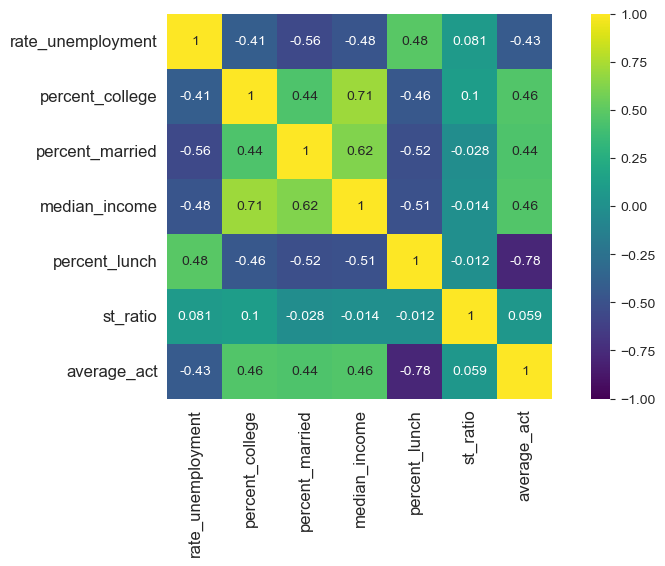

In [49]:
predictor_variables = ['rate_unemployment', 'percent_college', 'percent_married', 'median_income', 
                       'percent_lunch', 'state', 'charter', 'st_ratio']

numerical_predictors = df[predictor_variables].select_dtypes(include='number').columns.to_list()

corr_matrix = df[numerical_predictors + ["average_act"]].corr()

plt.figure(figsize=(10, 5))

sns.heatmap(
    corr_matrix, vmax=1, vmin=-1, square=True, annot=True, cmap="viridis"
)

plt.tick_params(labelsize=12)

plt.show()

### Pairplot of the cleaned data to examine the relationships and also overlay charter school information

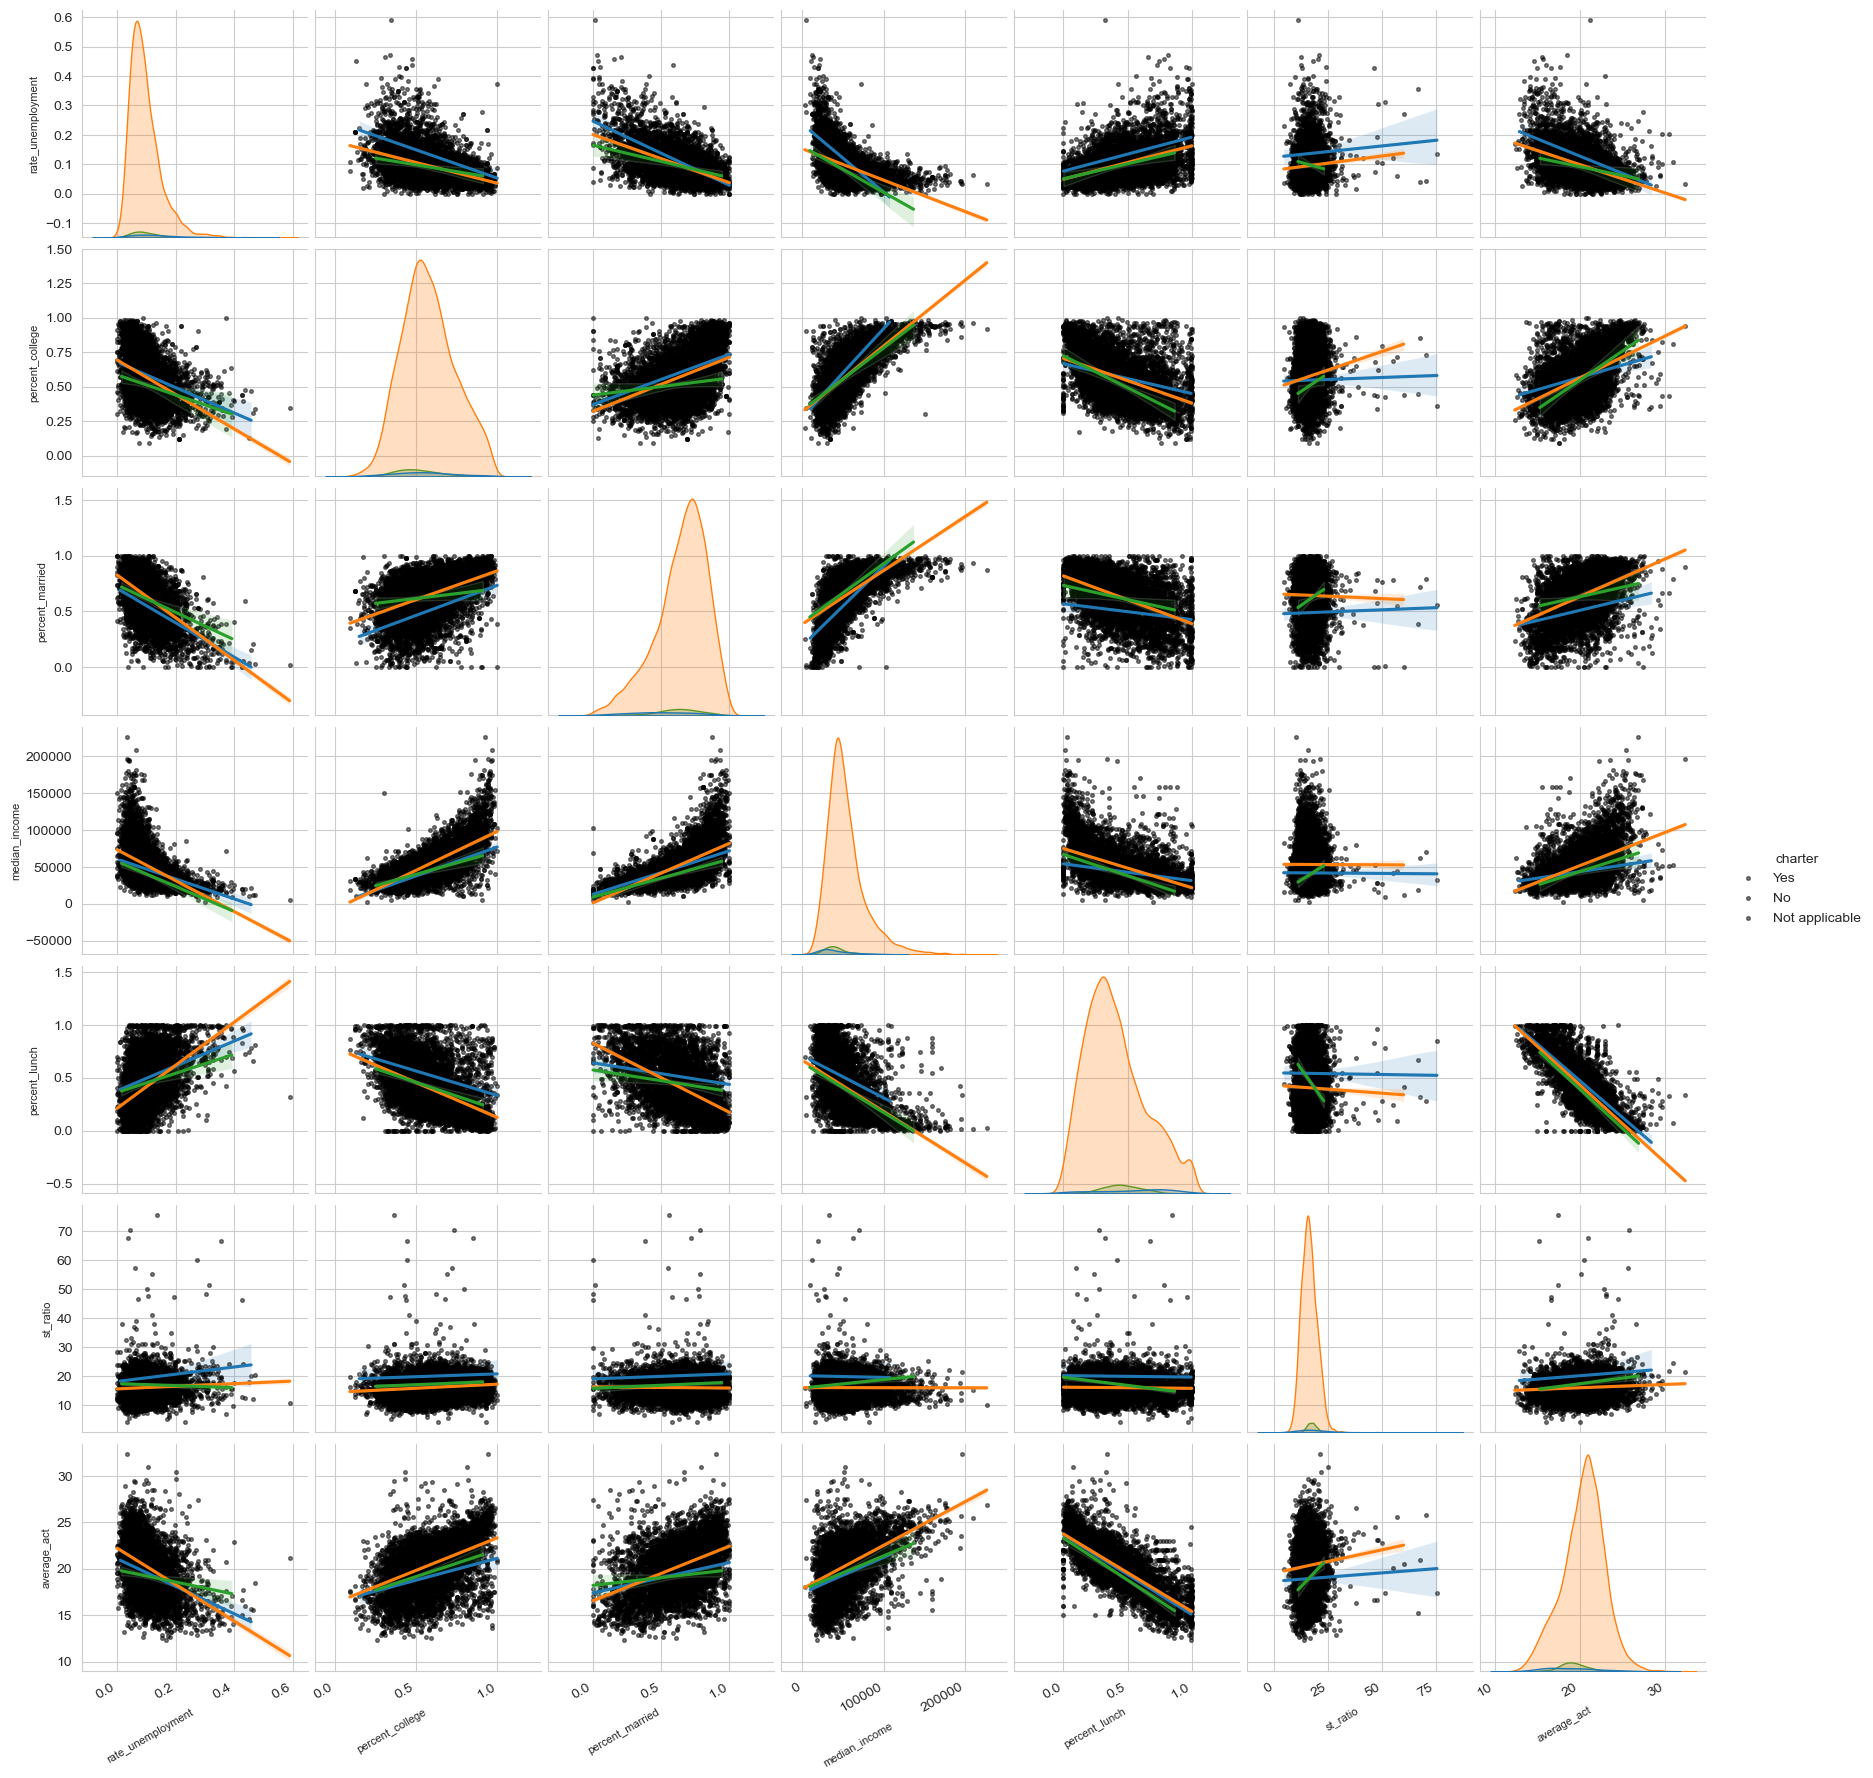

In [50]:
fig = sns.pairplot(
    data=df,
    vars=numerical_predictors + ['average_act'],
    hue='charter',
    kind="reg",
    plot_kws={"scatter_kws": {"alpha": 0.5, "color": "k", "s": 7},
    },
)

for ax in fig.axes.flat:
    if ax.get_xlabel() == 'CT Median Household Income':
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))  # Apply scientific notation
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right')  # X-axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8)  # Y-axis label size

    # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.show()

### Identify outliers

We can use the interquartile range to identify outliers. This is also evident in boxplots of the data. Median income is on a very different scale than the other predictors, so we will make two plots to explore the data.


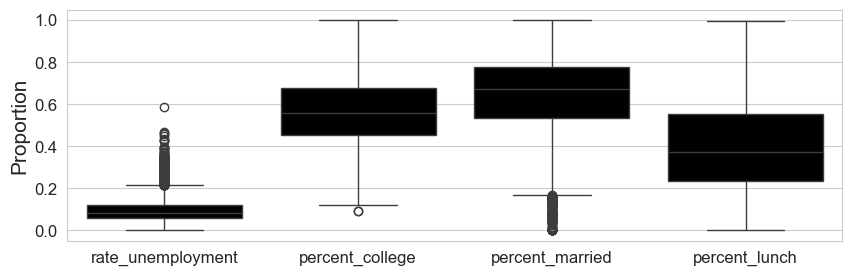

In [51]:
plt.figure(figsize=(10,3))

fractions = list(numerical_predictors)
fractions.remove('median_income')
fractions.remove('st_ratio')

sns.boxplot(data=df[fractions], color='k')

plt.ylabel('Proportion', fontsize=15)

plt.tick_params(labelsize=12)

plt.show()

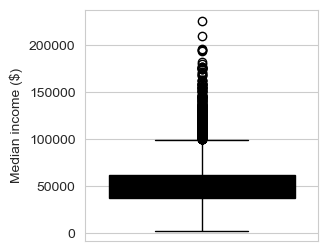

In [52]:
plt.figure(figsize=(3,3))

sns.boxplot(data=df, y='median_income', color='k')

plt.ylabel('Median income ($)')

plt.show()

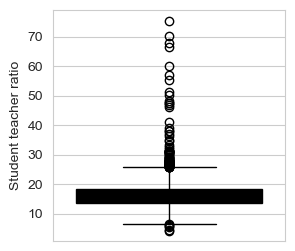

In [53]:
plt.figure(figsize=(3,3))

sns.boxplot(data=df, y='st_ratio', color='k')

plt.ylabel('Student teacher ratio')

plt.show()

## Summary

1.  The numerical predictors are related to `average_act`. The relationships appear roughly linear.

2.  The numerical predictors are correlated with each other, suggesting that not all predictors will be necessary.

3.  Some variables have skewed distributions, suggesting that transformations of input variables might be useful.

4. There are outliers in `rate_unemployment`, `percent_college`, `percent_married` and `median_income`. None of these are obviously incorrect values; they likely reflect skewed distributions. We may consider applying something like a log transformation to these predictors as we explore different models.

5. The relationships are similar across charter and non-charter schools, but might be significantly different.

# Modeling

## Single Input Models

### Median Income

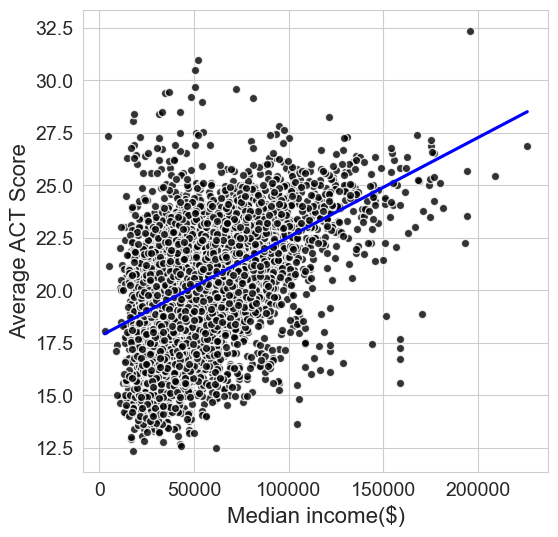

In [54]:
plt.figure(figsize= (6,6))

sns.regplot(data = df,
           x= 'median_income',
           y= 'average_act',
           color = "blue",
           ci= False,
           scatter_kws = {'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

plt.xlabel('Median income($)', fontsize =16)
plt.ylabel('Average ACT Score', fontsize=16)

plt.tick_params(labelsize=14)
plt.show()

In [55]:
model_median_income = smf.ols(formula='average_act ~ median_income', data=df).fit()

In [56]:
print(model_median_income.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.211
Model:                            OLS   Adj. R-squared:                  0.211
Method:                 Least Squares   F-statistic:                     1935.
Date:                Wed, 22 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:58:26   Log-Likelihood:                -16043.
No. Observations:                7227   AIC:                         3.209e+04
Df Residuals:                    7225   BIC:                         3.210e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        17.8023      0.063    284.780

The model is significant, but it is not great. The $R^2 = 0.211$, which is low.

### Unemployment

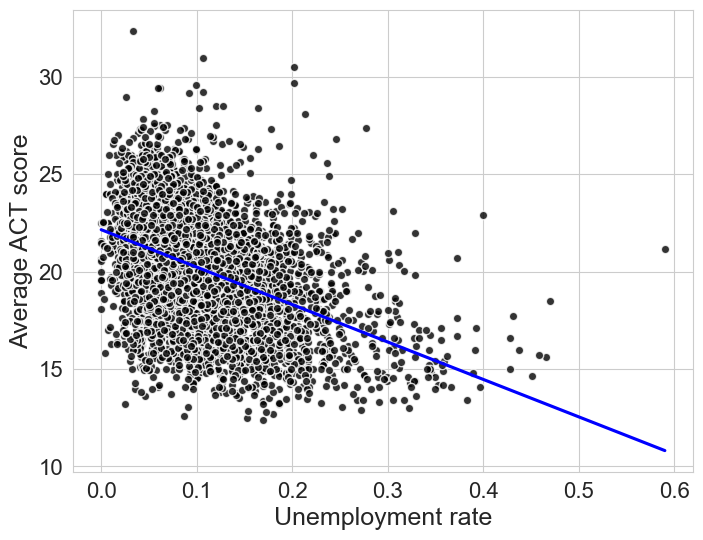

In [57]:
plt.figure(figsize=(8, 6))

sns.regplot(data=df,
            x='rate_unemployment',
            y='average_act',
            color='blue',
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1}
)

# Add axis labels
plt.xlabel('Unemployment rate', fontsize = 18)
plt.ylabel('Average ACT score', fontsize = 18)

# Increase the fontsize of the tick labels
plt.tick_params(labelsize = 16)

plt.show()

In [58]:
model_ru = smf.ols(formula='average_act ~ rate_unemployment', data=df).fit()
print(model_ru.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.188
Model:                            OLS   Adj. R-squared:                  0.188
Method:                 Least Squares   F-statistic:                     1669.
Date:                Wed, 22 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:58:27   Log-Likelihood:                -16149.
No. Observations:                7227   AIC:                         3.230e+04
Df Residuals:                    7225   BIC:                         3.232e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            22.1512      0.05

The model is significant, but it is not great. The $R^2 = 0.19$, which is low.

### Percent of adults with a college degree¶

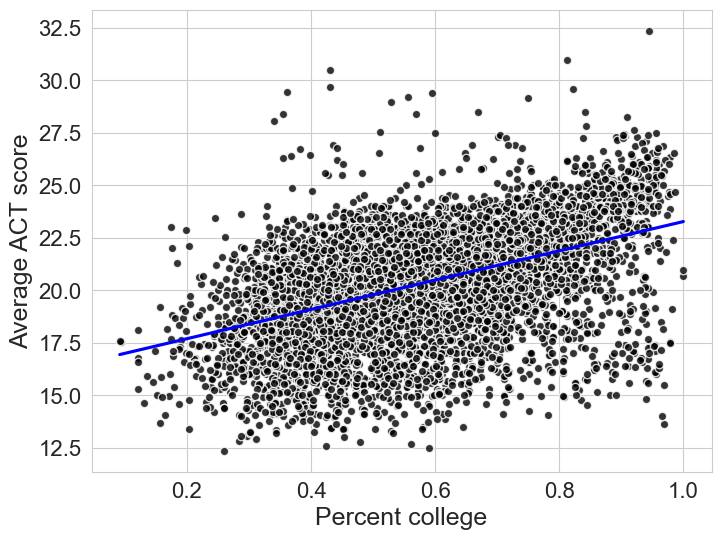

In [59]:
plt.figure(figsize=(8,6))

sns.regplot(data=df,
            x='percent_college',
            y='average_act',
            color='blue',
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

# Add axis labels
plt.xlabel('Percent college', fontsize = 18)
plt.ylabel('Average ACT score', fontsize = 18)


# Increase the fontsize of the tick labels
plt.tick_params(labelsize = 16);

In [60]:
model_pc = smf.ols(formula='average_act ~ percent_college', data=df).fit()
print(model_pc.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.210
Model:                            OLS   Adj. R-squared:                  0.210
Method:                 Least Squares   F-statistic:                     1922.
Date:                Wed, 22 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:58:28   Log-Likelihood:                -16048.
No. Observations:                7227   AIC:                         3.210e+04
Df Residuals:                    7225   BIC:                         3.211e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          16.3038      0.095    1

The model is significant, but it is not great. The $R^2 = 0.20$, which is low.

### Percent of adults married¶

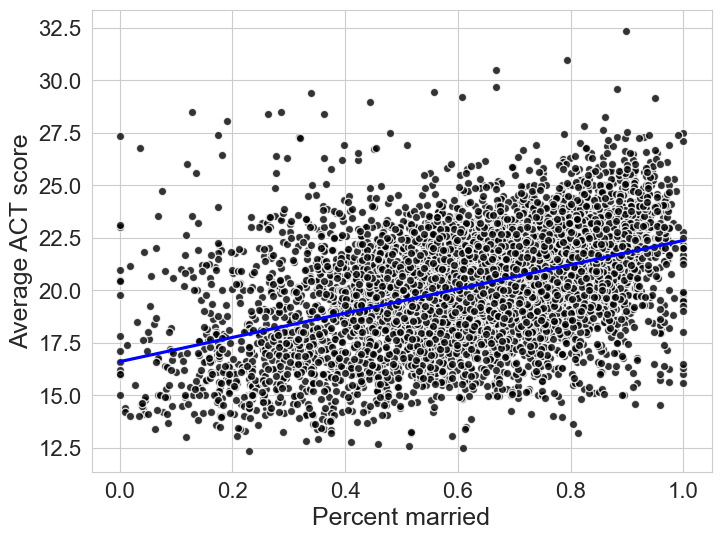

In [61]:
plt.figure(figsize=(8,6))


sns.regplot(data=df,
            x='percent_married',
            y='average_act',
            color='blue',
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

# Add axis labels
plt.xlabel('Percent married', fontsize = 18)
plt.ylabel('Average ACT score', fontsize = 18)


# Increase the fontsize of the tick labels
plt.tick_params(labelsize = 16);

In [62]:
model_pc = smf.ols(formula='average_act ~ percent_married', data=df).fit()
print(model_pc.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     1733.
Date:                Wed, 22 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:58:29   Log-Likelihood:                -16124.
No. Observations:                7227   AIC:                         3.225e+04
Df Residuals:                    7225   BIC:                         3.226e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          16.6044      0.093    1

The model is significant, but it is not great. The $R^2 = 0.19$, which is low.

### Percent of students with free or reduced price lunch¶

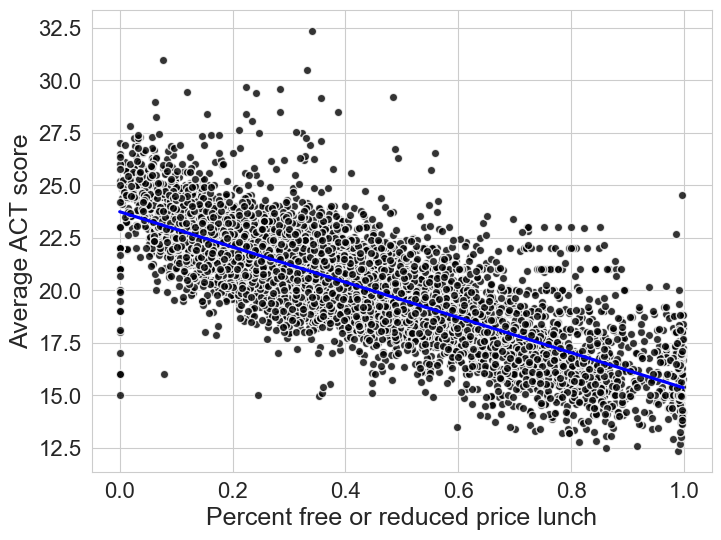

In [63]:
plt.figure(figsize=(8,6))

sns.regplot(data=df,
            x='percent_lunch',
            y='average_act',
            color='blue',
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

# Add axis labels
plt.xlabel('Percent free or reduced price lunch', fontsize = 18)
plt.ylabel('Average ACT score', fontsize = 18)


# Increase the fontsize of the tick labels
plt.tick_params(labelsize = 16);

In [64]:
model_pl = smf.ols(formula='average_act ~ percent_lunch', data=df).fit()

print(model_pl.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.614
Model:                            OLS   Adj. R-squared:                  0.614
Method:                 Least Squares   F-statistic:                 1.149e+04
Date:                Wed, 22 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:58:30   Log-Likelihood:                -13461.
No. Observations:                7227   AIC:                         2.693e+04
Df Residuals:                    7225   BIC:                         2.694e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        23.7431      0.037    641.764

There is a strong negative linear relationship between the percent of students with free or reduced price lunch and the average ACT score ($R^2 = 0.61$).

### Student to Teacher Ratio

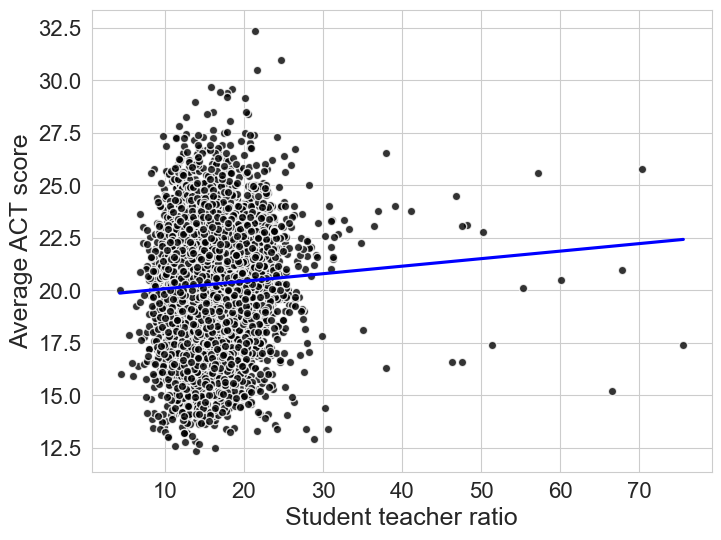

In [65]:
plt.figure(figsize=(8,6))

sns.regplot(data=df,
            x='st_ratio',
            y='average_act',
            color='blue',
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

# Add axis labels
plt.xlabel('Student teacher ratio', fontsize = 18)
plt.ylabel('Average ACT score', fontsize = 18)


# Increase the fontsize of the tick labels
plt.tick_params(labelsize = 16);

In [66]:
model_pl = smf.ols(formula='average_act ~ st_ratio', data=df).fit()

print(model_pl.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     25.14
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           5.46e-07
Time:                        21:58:30   Log-Likelihood:                -16888.
No. Observations:                7227   AIC:                         3.378e+04
Df Residuals:                    7225   BIC:                         3.379e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     19.7178      0.120    164.971      0.0

There is a almost no linear relationship between the student teacher ratio and the average ACT score ($R^2 = 0.002$).

# Multiple Linear Regression

We have determined that no one singular metric is best at predicting ACT scores based on the $R^2$ scores we saw in the above single input models. So now we are going to build a multiple linear regression wherein we will test all of the factors together to see if we can predict ACT scores better with all the variables contributing.

In [67]:
model = smf.ols(
    formula='average_act ~ rate_unemployment + percent_college + percent_married + median_income + percent_lunch + st_ratio',
    data=df).fit()

In [68]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.630
Model:                            OLS   Adj. R-squared:                  0.630
Method:                 Least Squares   F-statistic:                     2047.
Date:                Wed, 22 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:58:30   Log-Likelihood:                -13309.
No. Observations:                7227   AIC:                         2.663e+04
Df Residuals:                    7220   BIC:                         2.668e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            22.3492      0.14

In [69]:
y_hat = model.predict()

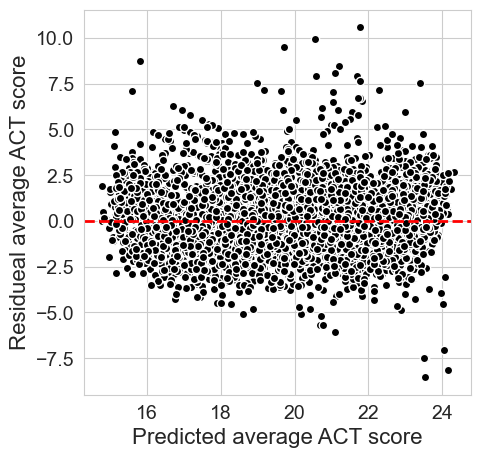

In [70]:
plt.figure(figsize= (5,5))

plt.plot(y_hat, model.resid, 'ko', mec='w')
plt.axhline(0, color='r', linestyle='dashed', lw =2)

plt.xlabel('Predicted average ACT score', fontsize =16)
plt.ylabel('Residueal average ACT score', fontsize=16)

plt.tick_params(labelsize=14)
plt.show()

In [71]:
mean_absolute_error(df['average_act'], model.predict())

1.1425864241235006

## Summary

1. The multiple linear regression model with all socioeconomic predictors can predict ACT scores with an average error of roughly 1 point using these predictors.

2. The residual plot suggests that there will be limited improvement from adding transformations of these predictors.

3. Not all predictors have significant coefficients.

4. Adding predictors to the model may improve the performance.

## Reduced Model

Some of the factors do not add to the model as much as others so we will try to reduce the model to the minimum amount of factors needed to produce an accurate model

In [72]:
model_reduced = smf.ols(
        formula="average_act ~ rate_unemployment+ percent_college + percent_lunch", 
        data=df).fit()

In [73]:
print(model_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.628
Model:                            OLS   Adj. R-squared:                  0.628
Method:                 Least Squares   F-statistic:                     4064.
Date:                Wed, 22 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:58:31   Log-Likelihood:                -13328.
No. Observations:                7227   AIC:                         2.666e+04
Df Residuals:                    7223   BIC:                         2.669e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            22.6404      0.10

In [74]:
y_hat= model_reduced.predict()

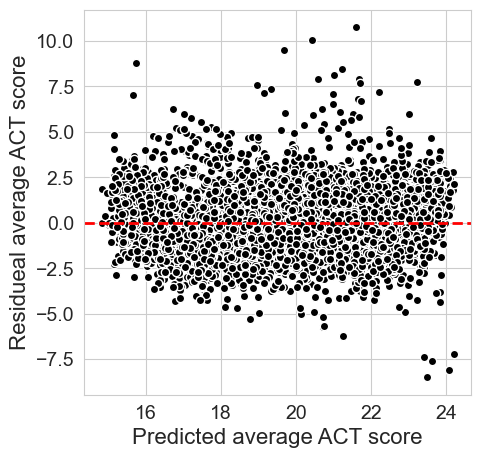

In [75]:
plt.figure(figsize= (5,5))

plt.plot(y_hat, model_reduced.resid, 'ko', mec='w')
plt.axhline(0, color='r', linestyle='dashed', lw =2)

plt.xlabel('Predicted average ACT score', fontsize =16)
plt.ylabel('Residueal average ACT score', fontsize=16)

plt.tick_params(labelsize=14)
plt.show()

In [76]:
mae_full= mean_absolute_error(df['average_act'],model.predict())
mae_reduced = mean_absolute_error(df['average_act'], model_reduced.predict())

r2_full = model.rsquared
r2_reduced = model_reduced.rsquared

pd.DataFrame({'Mean Absolute Error': [mae_full, mae_reduced],
             'R-squared': [r2_full, r2_reduced]},
             index=['full model', 'reduced model']).round(4)

,Mean Absolute Error,R-squared
full model,1.1426,0.6298
reduced model,1.1455,0.6280


In [77]:
anova_lm(model_reduced, model)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,7223.0,16915.301590,0.0,NaN,NaN,NaN
1,7220.0,16830.454711,3.0,84.846878,12.132658,6.442283e-08


## Summary

1. The model predicting the average ACT score from `rate_unemployment`, `percent_college` and, `percent_lunch` is not significantly different than the model with all five socioeconomic variables as predictors.

2. Adding predictors to the model may improve the performance.

3. We have not yet determined the relative importance of each predictor in the model.

# Scaling

The factors do not use the same scale so it is difficult to compare them effectively. We will transform the data so one unit change in a factor is equivalent to one unit change in all other factors so we can compare them directly.

In [78]:
predictor_variables = ['rate_unemployment','percent_college','percent_lunch']
scaled_columns = [var+ '_normalized' for var in predictor_variables]
print(scaled_columns)

['rate_unemployment_normalized', 'percent_college_normalized', 'percent_lunch_normalized']


In [79]:
scaler = StandardScaler().fit(df[predictor_variables])
df[scaled_columns]= scaler.transform(df[predictor_variables])

In [80]:
df[scaled_columns].agg(['mean', 'std']).round(3)

,rate_unemployment_normalized,percent_college_normalized,percent_lunch_normalized
mean,-0.0,-0.0,0.0
std,1.0,1.0,1.0


In [81]:
model_normalized = smf.ols(
        formula="average_act ~ rate_unemployment_normalized+ percent_college_normalized + percent_lunch_normalized", 
    data=df).fit()

In [82]:
print(model_normalized.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.628
Model:                            OLS   Adj. R-squared:                  0.628
Method:                 Least Squares   F-statistic:                     4064.
Date:                Wed, 22 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:58:31   Log-Likelihood:                -13328.
No. Observations:                7227   AIC:                         2.666e+04
Df Residuals:                    7223   BIC:                         2.669e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [83]:
mae_normalzied= mean_absolute_error(df['average_act'],model_normalized.predict())
mae_reduced = mean_absolute_error(df['average_act'], model_reduced.predict())

r2_normalized = model_normalized.rsquared
r2_reduced = model_reduced.rsquared

pd.DataFrame({'Mean Absolute Error': [mae_normalzied, mae_reduced],
             'R-squared': [r2_normalized, r2_reduced]},
             index=['normalized model', 'reduced model']).round(4)

,Mean Absolute Error,R-squared
normalized model,1.1455,0.628
reduced model,1.1455,0.628


## Summary

1. The percent of students at school receieving free or reduced lunch was the strongest predictor in this analysis. When all the factors are scaled to each other the coeffcient for `rate unemployment` is -0.122, `percent_college` is 0.28 and `percent_lunch` is -1.77

# Conclusion

The analysis shows that college entrance test scores (ACT and SAT) are related to socioeconomic variables.

In particular, using only the percent of students at a school receiving free or reduced price lunch, we can predict ACT scores to within a single point, on average.

The percent of students at a school receiving free or reduced price lunch was the strongest predictor in this analysis. It was also the only variable measured for students at the school, rather than for the neighborhood. It is an open question how important the other predictors would be if they were measured for the students at the school, rather than for the neighborhood.

